# Track B — Patch Representation Probing
**CS 639 · UW–Madison · Spring 2026 · ViT Hallucination Research**

---

| Item | Detail |
|------|--------|
| **Goal** | Extract patch embeddings from ViT layers 6, 12, 18, 24; train linear probes to predict object presence; stratify by hallucination outcome |
| **Input** | `chair_labels.csv` + `sampled_image_ids.json` from Track A (Notebook 1) |
| **Output** | `probe_results.csv`, `patch_embeddings_cache.npz`, 4 report figures → `/content/drive/MyDrive/CS639_TrackA/` |
| **GPU** | **A100 (40 GB)** for embedding extraction; probes train on CPU/T4 fine |
| **Runtime** | ~1.5–2 hours on A100 (embedding extraction), ~10 min for probe training |

### Research Question
> *Are patch-level embeddings from the ViT less discriminative (for object-presence prediction) when the downstream VLM hallucinates?*

### How to run
1. Run Cell 1 → **Runtime → Restart session**
2. Run Cells 2–11 top to bottom
3. If session disconnects: re-run Cells 2–5, Cell 6 auto-resumes from cache


## Cell 1 — Install Dependencies
> **After running: Runtime → Restart session → skip to Cell 2**

In [1]:
!pip install -q transformers==4.37.2 tokenizers==0.15.2 accelerate==0.27.2 \
    pycocotools scipy Pillow tqdm pandas sentencepiece protobuf scikit-learn

import transformers, tokenizers, sklearn
print(f"transformers: {transformers.__version__}")
print(f"tokenizers:   {tokenizers.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print()
print("✅ Install complete.")
print("⚠️  NOW: Runtime → Restart session → then run Cell 2")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 99.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 113.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.0/280.0 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 44.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.4.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.37.2 which is incompatible.
transformers: 4.37.2
tokenizers:   0.15.2
scikit-learn: 1.6.1

✅ Install complete.
⚠️  NOW: Runtime → Restart session → then run Cell 2


## Cell 2 — GPU + Drive + Verify Track A Outputs

In [2]:
import subprocess, torch, sys, os

print(subprocess.run(['nvidia-smi'], capture_output=True, text=True).stdout)

if not torch.cuda.is_available():
    print("❌ No GPU. Go to: Runtime → Change runtime type → A100 GPU → Save")
    sys.exit(1)

gpu_name = torch.cuda.get_device_name(0)
vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"✅ GPU: {gpu_name} | VRAM: {vram_gb:.1f} GB")

import transformers
assert transformers.__version__ == "4.37.2", f"❌ Wrong version: {transformers.__version__}. Re-run Cell 1 + restart."

from google.colab import drive
drive.mount('/content/drive')

OUTPUT_DIR = "/content/drive/MyDrive/CS639_TrackA"
TRACKB_DIR = f"{OUTPUT_DIR}/TrackB"
os.makedirs(TRACKB_DIR, exist_ok=True)

# Verify Track A handoff files
for f in ['chair_labels.csv', 'sampled_image_ids.json']:
    path = f"{OUTPUT_DIR}/{f}"
    assert os.path.exists(path), f"❌ {f} not found at {path} — run Track A Notebook 1 first!"
    print(f"✅ Found: {f}")

print(f"\n✅ Output dir: {TRACKB_DIR}")


Sun Apr 19 18:54:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   30C    P0             51W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## Cell 3 — Version Gate

In [3]:
import transformers, tokenizers

tv, kv = transformers.__version__, tokenizers.__version__
print(f"transformers: {tv}")
print(f"tokenizers:   {kv}")

if tv != "4.37.2":
    raise SystemExit(f"❌ Wrong transformers: {tv}. Re-run Cell 1 → restart.")
if kv != "0.15.2":
    raise SystemExit(f"❌ Wrong tokenizers: {kv}. Re-run Cell 1 → restart.")

print("✅ Versions correct. Proceed.")


transformers: 4.37.2
tokenizers:   0.15.2
✅ Versions correct. Proceed.


## Cell 4 — Download COCO + Load Track A Data

In [4]:
import json, pandas as pd, numpy as np, os
from pycocotools.coco import COCO

COCO_DIR = "/content/coco"
IMG_DIR  = f"{COCO_DIR}/val2017"
ANN_FILE = f"{COCO_DIR}/annotations/instances_val2017.json"
os.makedirs(COCO_DIR, exist_ok=True)

if not os.path.exists(IMG_DIR):
    print("Downloading COCO val2017 images (~1 GB)...")
    !wget -q --show-progress http://images.cocodataset.org/zips/val2017.zip -P {COCO_DIR}
    !unzip -q {COCO_DIR}/val2017.zip -d {COCO_DIR}
    !rm -f {COCO_DIR}/val2017.zip
    print("✅ Images extracted.")
else:
    print("✅ Images already present.")

if not os.path.exists(ANN_FILE):
    print("Downloading annotations (~240 MB)...")
    !wget -q --show-progress http://images.cocodataset.org/annotations/annotations_trainval2017.zip -P {COCO_DIR}
    !unzip -q {COCO_DIR}/annotations_trainval2017.zip -d {COCO_DIR}
    !rm -f {COCO_DIR}/annotations_trainval2017.zip
    print("✅ Annotations extracted.")
else:
    print("✅ Annotations already present.")

coco = COCO(ANN_FILE)
cat_id_to_name = {cat['id']: cat['name'] for cat in coco.dataset['categories']}
ALL_COCO_CATS = sorted(cat_id_to_name.values())

def get_gt_objects(image_id):
    ann_ids = coco.getAnnIds(imgIds=image_id)
    anns = coco.loadAnns(ann_ids)
    return set(cat_id_to_name[a['category_id']] for a in anns)

# Load Track A outputs
with open(f"{OUTPUT_DIR}/sampled_image_ids.json") as f:
    SAMPLE_IDS = json.load(f)

chair_df = pd.read_csv(f"{OUTPUT_DIR}/chair_labels.csv")
chair_df = chair_df[chair_df['chair_i'] >= 0].reset_index(drop=True)

n_hall  = chair_df['is_hallucinating'].sum()
n_clean = (~chair_df['is_hallucinating']).sum()
print(f"\n✅ COCO loaded | CHAIR: {len(chair_df)} images")
print(f"   Hallucinating: {n_hall} | Clean: {n_clean}")
print(f"   COCO categories: {len(ALL_COCO_CATS)}")


val2017.zip         100%[===================>] 777.80M  46.5MB/s    in 18s     
✅ Images extracted.
annotations_trainva 100%[===================>] 241.19M  41.6MB/s    in 6.2s    
✅ Annotations extracted.
loading annotations into memory...
Done (t=0.52s)
creating index...
index created!

✅ COCO loaded | CHAIR: 500 images
   Hallucinating: 329 | Clean: 171
   COCO categories: 80


## Cell 5 — Load LLaVA-1.5-7B (float16) + Hook ViT Layers

We hook the **output hidden states** of ViT layers 6, 12, 18, 24 (0-indexed: 5, 11, 17, 23).  
Each hook captures the full sequence output: shape `(1, 577, 1024)` → 576 patch tokens + 1 CLS token.

In [5]:
import torch
from transformers import (
    LlavaForConditionalGeneration, LlavaProcessor,
    CLIPImageProcessor, LlamaTokenizer
)

MODEL_ID = "llava-hf/llava-1.5-7b-hf"
PROBE_LAYERS = [6, 12, 18, 24]  # 1-indexed, human-readable
HOOK_INDICES = [l - 1 for l in PROBE_LAYERS]  # 0-indexed for actual hooks

print(f"Loading {MODEL_ID} in float16 (no quantization)...")
model = LlavaForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto",
    low_cpu_mem_usage=True,
)

tokenizer = LlamaTokenizer.from_pretrained(MODEL_ID)
image_processor = CLIPImageProcessor.from_pretrained(MODEL_ID)
processor = LlavaProcessor(tokenizer=tokenizer, image_processor=image_processor)
model.eval()

vit_layers = model.vision_tower.vision_model.encoder.layers
NUM_VIT_LAYERS = len(vit_layers)
assert NUM_VIT_LAYERS == 24, f"Expected 24 ViT layers, got {NUM_VIT_LAYERS}"

# ── Verify hidden dim by probing one image ──
hidden_store = {}

def make_hidden_hook(layer_idx):
    """Capture full hidden state output from a ViT layer (before projection)."""
    def hook_fn(module, input, output):
        # CLIPEncoderLayer returns (hidden_state, ...) or just hidden_state
        h = output[0] if isinstance(output, tuple) else output
        hidden_store[layer_idx] = h.detach().float().cpu()  # (1, seq_len, hidden_dim)
    return hook_fn

from PIL import Image
test_img = Image.open(f"{IMG_DIR}/{coco.loadImgs(SAMPLE_IDS[0])[0]['file_name']}").convert("RGB")
PROMPT = "USER: <image>\nDescribe this image.\nASSISTANT:"

hidden_store.clear()
hooks = [vit_layers[i].register_forward_hook(make_hidden_hook(i)) for i in HOOK_INDICES]
inp = processor(text=PROMPT, images=test_img, return_tensors="pt")
inp = {k: v.to(model.device) if hasattr(v, 'to') else v for k, v in inp.items()}
with torch.no_grad():
    model.generate(**inp, max_new_tokens=5, do_sample=False)
for h in hooks: h.remove()

sample_h = hidden_store[HOOK_INDICES[0]]
_, SEQ_LEN, HIDDEN_DIM = sample_h.shape
NUM_PATCHES = SEQ_LEN - 1  # subtract CLS

print(f"\n✅ Model loaded (float16).")
print(f"   VRAM: {torch.cuda.memory_allocated()/1e9:.2f} / {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"\n   ViT hidden state shape: {sample_h.shape}")
print(f"   Seq len: {SEQ_LEN} | Patches: {NUM_PATCHES} | Hidden dim: {HIDDEN_DIM}")
print(f"   Probe layers: {PROBE_LAYERS} (hook indices: {HOOK_INDICES})")

hidden_store.clear(); torch.cuda.empty_cache()


Loading llava-hf/llava-1.5-7b-hf in float16 (no quantization)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/4.99G [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


preprocessor_config.json:   0%|          | 0.00/505 [00:00<?, ?B/s]


✅ Model loaded (float16).
   VRAM: 14.21 / 85.1 GB

   ViT hidden state shape: torch.Size([1, 577, 1024])
   Seq len: 577 | Patches: 576 | Hidden dim: 1024
   Probe layers: [6, 12, 18, 24] (hook indices: [5, 11, 17, 23])


## Cell 6 — Extract Patch Embeddings for All 500 Images

For each image and each of the 4 probe layers, we extract:
- **CLS token**: `hidden[0, 0, :]` → shape `(1024,)` — global image representation at that layer  
- **Mean patch embedding**: `hidden[0, 1:, :].mean(0)` → shape `(1024,)` — average spatial representation

Both are saved. Probes will train on mean-pooled patch embeddings (more informative for object presence).

**Checkpoint every 25 images** — safe to disconnect and resume.

In [6]:
import gc
from tqdm import tqdm

CACHE_PATH = f"{TRACKB_DIR}/patch_embeddings_cache.npz"
CKPT_PATH  = f"{TRACKB_DIR}/patch_embeddings_ckpt.npz"

# ── Resume logic ──
if os.path.exists(CKPT_PATH):
    ckpt = np.load(CKPT_PATH, allow_pickle=True)
    done_ids = set(ckpt['image_ids'].tolist())
    cls_store  = {iid: {l: ckpt[f'cls_l{l}'][i]  for j, l in enumerate(PROBE_LAYERS)}
                  for i, iid in enumerate(ckpt['image_ids'])}
    mean_store = {iid: {l: ckpt[f'mean_l{l}'][i] for j, l in enumerate(PROBE_LAYERS)}
                  for i, iid in enumerate(ckpt['image_ids'])}
    print(f"🔄 Resuming: {len(done_ids)}/500 done.")
else:
    cls_store, mean_store, done_ids = {}, {}, set()
    print("🆕 Starting fresh.")

remaining = [i for i in SAMPLE_IDS if i not in done_ids]
print(f"   Remaining: {len(remaining)} images\n")

PROMPT_EMB = "USER: <image>\nDescribe this image.\nASSISTANT:"

for idx, image_id in enumerate(tqdm(remaining, desc="Patch Extraction")):
    try:
        img_info = coco.loadImgs(image_id)[0]
        image = Image.open(f"{IMG_DIR}/{img_info['file_name']}").convert("RGB")

        hidden_store.clear()
        hooks = [vit_layers[i].register_forward_hook(make_hidden_hook(i)) for i in HOOK_INDICES]
        inp = processor(text=PROMPT_EMB, images=image, return_tensors="pt")
        inp = {k: v.to(model.device) if hasattr(v, 'to') else v for k, v in inp.items()}

        with torch.no_grad():
            model.generate(**inp, max_new_tokens=5, do_sample=False)
        for h in hooks: h.remove()

        cls_store[image_id]  = {}
        mean_store[image_id] = {}
        for hook_idx, layer_num in zip(HOOK_INDICES, PROBE_LAYERS):
            h = hidden_store[hook_idx]  # (1, seq_len, hidden_dim)
            cls_store[image_id][layer_num]  = h[0, 0, :].numpy()          # (hidden_dim,)
            mean_store[image_id][layer_num] = h[0, 1:, :].mean(0).numpy() # (hidden_dim,)

        hidden_store.clear()

    except Exception as e:
        print(f"\n⚠️  Error on {image_id}: {e}")
        dummy = np.zeros(HIDDEN_DIM)
        cls_store[image_id]  = {l: dummy for l in PROBE_LAYERS}
        mean_store[image_id] = {l: dummy for l in PROBE_LAYERS}

    # Checkpoint every 25
    if (idx + 1) % 25 == 0:
        ids_so_far = list(cls_store.keys())
        save_dict = {'image_ids': np.array(ids_so_far)}
        for l in PROBE_LAYERS:
            save_dict[f'cls_l{l}']  = np.stack([cls_store[i][l]  for i in ids_so_far])
            save_dict[f'mean_l{l}'] = np.stack([mean_store[i][l] for i in ids_so_far])
        np.savez(CKPT_PATH, **save_dict)
        torch.cuda.empty_cache(); gc.collect()
        v = torch.cuda.memory_allocated() / 1e9
        print(f"\n   💾 Checkpoint: {len(ids_so_far)}/500 | VRAM: {v:.2f} GB")

print(f"\n✅ Extraction complete: {len(cls_store)} images")


🆕 Starting fresh.
   Remaining: 500 images



Patch Extraction:   5%|▌         | 25/500 [00:06<03:03,  2.59it/s]


   💾 Checkpoint: 25/500 | VRAM: 14.21 GB


Patch Extraction:  10%|█         | 50/500 [00:13<02:50,  2.64it/s]


   💾 Checkpoint: 50/500 | VRAM: 14.21 GB


...


   💾 Checkpoint: 450/500 | VRAM: 14.21 GB


Patch Extraction:  95%|█████████▌| 475/500 [02:11<00:09,  2.54it/s]


   💾 Checkpoint: 475/500 | VRAM: 14.21 GB


Patch Extraction: 100%|██████████| 500/500 [02:18<00:00,  3.61it/s]


   💾 Checkpoint: 500/500 | VRAM: 14.21 GB

✅ Extraction complete: 500 images


## Cell 7 — Save Final Embeddings Cache

In [7]:
# Save in SAMPLE_IDS order
valid_ids = [i for i in SAMPLE_IDS if i in cls_store]
save_dict = {'image_ids': np.array(valid_ids)}
for l in PROBE_LAYERS:
    save_dict[f'cls_l{l}']  = np.stack([cls_store[i][l]  for i in valid_ids])
    save_dict[f'mean_l{l}'] = np.stack([mean_store[i][l] for i in valid_ids])

np.savez(CACHE_PATH, **save_dict)

print(f"✅ Saved: {CACHE_PATH}")
for l in PROBE_LAYERS:
    print(f"   Layer {l:2d} — cls: {save_dict[f'cls_l{l}'].shape}, mean: {save_dict[f'mean_l{l}'].shape}")

# Free GPU memory — probes run on CPU
del model
torch.cuda.empty_cache(); gc.collect()
print("\n✅ GPU freed. Probe training runs on CPU.")


✅ Saved: /content/drive/MyDrive/CS639_TrackA/TrackB/patch_embeddings_cache.npz
   Layer  6 — cls: (500, 1024), mean: (500, 1024)
   Layer 12 — cls: (500, 1024), mean: (500, 1024)
   Layer 18 — cls: (500, 1024), mean: (500, 1024)
   Layer 24 — cls: (500, 1024), mean: (500, 1024)

✅ GPU freed. Probe training runs on CPU.


## Cell 8 — Build Probe Dataset

**Probe task**: Binary classification — does this image contain object *X*?  
- **Feature**: mean-pooled patch embedding at layer L → shape `(1024,)`  
- **Label**: 1 if object X is in COCO ground truth for that image, 0 otherwise  

We train one probe **per (layer, object category)**. To avoid degenerate classes, we only use categories  
that appear in at least 20 images AND are absent in at least 20 images (balanced enough for a meaningful probe).

Stratification: we additionally record per-image hallucination status so we can  
compare probe accuracy on the hallucinating subset vs the clean subset.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# ── Reload cache if session restarted ──
cache = np.load(CACHE_PATH, allow_pickle=True)
cached_ids = cache['image_ids'].tolist()

# Build id → index map
id2idx = {iid: i for i, iid in enumerate(cached_ids)}

# Merge with chair_df
probe_df = chair_df[chair_df['image_id'].isin(id2idx)].copy().reset_index(drop=True)
probe_df['cache_idx'] = probe_df['image_id'].map(id2idx)

# Build ground-truth binary label matrix: (n_images, n_categories)
n = len(probe_df)
cat_labels = {cat: np.zeros(n, dtype=int) for cat in ALL_COCO_CATS}
for i, row in probe_df.iterrows():
    gt = set(row['gt_objects'].split('|')) if isinstance(row['gt_objects'], str) else set()
    for cat in gt:
        if cat in cat_labels:
            cat_labels[cat][i] = 1

# Filter to probing-worthy categories
MIN_POSITIVE = 20
probing_cats = [
    cat for cat, labels in cat_labels.items()
    if labels.sum() >= MIN_POSITIVE and (n - labels.sum()) >= MIN_POSITIVE
]
print(f"Total COCO categories: {len(ALL_COCO_CATS)}")
print(f"Categories meeting min-positive threshold ({MIN_POSITIVE}): {len(probing_cats)}")
print(f"Probing categories: {sorted(probing_cats)}")


Total COCO categories: 80
Categories meeting min-positive threshold (20): 17
Probing categories: ['backpack', 'bed', 'bench', 'book', 'bottle', 'bowl', 'car', 'cell phone', 'chair', 'cup', 'dining table', 'handbag', 'laptop', 'person', 'sink', 'truck', 'umbrella']


## Cell 9 — Train Linear Probes (All Layers × All Categories)

**Design**:  
- 5-fold cross-validated `LogisticRegression` (L2, solver=`lbfgs`)  
- Features are L2-normalized mean patch embeddings  
- Reports both **accuracy** and **ROC-AUC** per (layer, category)  
- Also reports accuracy separately on hallucinating vs. clean subsets  

**Expected runtime**: ~8–15 min on CPU (parallelized per category).

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score
import warnings
warnings.filterwarnings('ignore')

N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=639)

hall_mask  = probe_df['is_hallucinating'].values.astype(bool)
clean_mask = ~hall_mask

all_results = []

for layer_num in PROBE_LAYERS:
    print(f"\n{'='*50}")
    print(f"  Layer {layer_num}")
    print(f"{'='*50}")

    # Extract mean-pooled patch embeddings for this layer
    X_raw = cache[f'mean_l{layer_num}'][probe_df['cache_idx'].values]  # (n, 1024)

    # Standardize
    scaler = StandardScaler()
    X = scaler.fit_transform(X_raw)

    for cat in probing_cats:
        y = cat_labels[cat][probe_df.index]  # binary label

        # Skip if degenerate after masking
        if y.sum() < 5 or (len(y) - y.sum()) < 5:
            continue

        try:
            clf = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', n_jobs=-1)
            y_pred = cross_val_predict(clf, X, y, cv=skf, method='predict')
            y_prob = cross_val_predict(clf, X, y, cv=skf, method='predict_proba')[:, 1]

            acc_all   = accuracy_score(y, y_pred)
            auc_all   = roc_auc_score(y, y_prob)

            # Stratified accuracy on halluc vs clean subsets (using same CV predictions)
            acc_hall  = accuracy_score(y[hall_mask],  y_pred[hall_mask])  if hall_mask.sum()  > 5 else np.nan
            acc_clean = accuracy_score(y[clean_mask], y_pred[clean_mask]) if clean_mask.sum() > 5 else np.nan
            auc_hall  = roc_auc_score(y[hall_mask],  y_prob[hall_mask])   if (y[hall_mask].sum() > 0 and (1-y[hall_mask]).sum() > 0) else np.nan
            auc_clean = roc_auc_score(y[clean_mask], y_prob[clean_mask])  if (y[clean_mask].sum() > 0 and (1-y[clean_mask]).sum() > 0) else np.nan

            all_results.append({
                'layer':       layer_num,
                'category':    cat,
                'n_positive':  int(y.sum()),
                'n_negative':  int((1 - y).sum()),
                'acc_all':     round(acc_all, 4),
                'auc_all':     round(auc_all, 4),
                'acc_hall':    round(acc_hall, 4)  if not np.isnan(acc_hall)  else np.nan,
                'acc_clean':   round(acc_clean, 4) if not np.isnan(acc_clean) else np.nan,
                'auc_hall':    round(auc_hall, 4)  if not np.isnan(auc_hall)  else np.nan,
                'auc_clean':   round(auc_clean, 4) if not np.isnan(auc_clean) else np.nan,
                'acc_delta':   round(acc_hall - acc_clean, 4) if (not np.isnan(acc_hall) and not np.isnan(acc_clean)) else np.nan,
            })

        except Exception as e:
            print(f"  ⚠️  {cat}: {e}")

    layer_res = [r for r in all_results if r['layer'] == layer_num]
    mean_acc  = np.mean([r['acc_all'] for r in layer_res])
    mean_auc  = np.mean([r['auc_all'] for r in layer_res])
    print(f"  Mean Acc: {mean_acc:.4f} | Mean AUC: {mean_auc:.4f} | N categories: {len(layer_res)}")

results_df = pd.DataFrame(all_results)
print(f"\n✅ Probe training complete: {len(results_df)} (layer, category) probes")
print(results_df.groupby('layer')[['acc_all', 'auc_all', 'acc_hall', 'acc_clean']].mean().round(4))



  Layer 6
  Mean Acc: 0.9086 | Mean AUC: 0.7340 | N categories: 17

  Layer 12
  Mean Acc: 0.9326 | Mean AUC: 0.8331 | N categories: 17

  Layer 18
  Mean Acc: 0.9461 | Mean AUC: 0.9049 | N categories: 17

  Layer 24
  Mean Acc: 0.9388 | Mean AUC: 0.8752 | N categories: 17

✅ Probe training complete: 68 (layer, category) probes
       acc_all  auc_all  acc_hall  acc_clean
layer                                       
6       0.9086   0.7340    0.8954     0.9340
12      0.9326   0.8331    0.9204     0.9560
18      0.9461   0.9049    0.9369     0.9639
24      0.9388   0.8752    0.9260     0.9635


## Cell 10 — Save Probe Results CSV

In [10]:
PROBE_CSV = f"{TRACKB_DIR}/probe_results.csv"
results_df.to_csv(PROBE_CSV, index=False)
print(f"✅ Saved: {PROBE_CSV}")
print(f"   Shape: {results_df.shape}")
print("\nSample rows:")
print(results_df.head(8).to_string(index=False))


✅ Saved: /content/drive/MyDrive/CS639_TrackA/TrackB/probe_results.csv
   Shape: (68, 11)

Sample rows:
 layer   category  n_positive  n_negative  acc_all  auc_all  acc_hall  acc_clean  auc_hall  auc_clean  acc_delta
     6   backpack          27         473    0.916   0.6071    0.9088     0.9298    0.5304     0.7572    -0.0210
     6        bed          22         478    0.946   0.8425    0.9362     0.9649    0.8139     0.9060    -0.0287
     6      bench          25         475    0.924   0.5828    0.9210     0.9298    0.5291     0.7855    -0.0089
     6       book          24         476    0.944   0.8366    0.9301     0.9708    0.8366     0.7480    -0.0407
     6     bottle          38         462    0.902   0.7487    0.8815     0.9415    0.7202     0.8333    -0.0601
     6       bowl          33         467    0.928   0.8199    0.9119     0.9591    0.7968     0.8423    -0.0472
     6        car          51         449    0.876   0.7424    0.8723     0.8830    0.7937     0.6132    -

## Cell 11 — Figure 1: Probe Accuracy Curves Across Layers

Main Track B deliverable figure — mean probe accuracy and AUC per layer,  
showing how object discriminability evolves through the ViT depth.

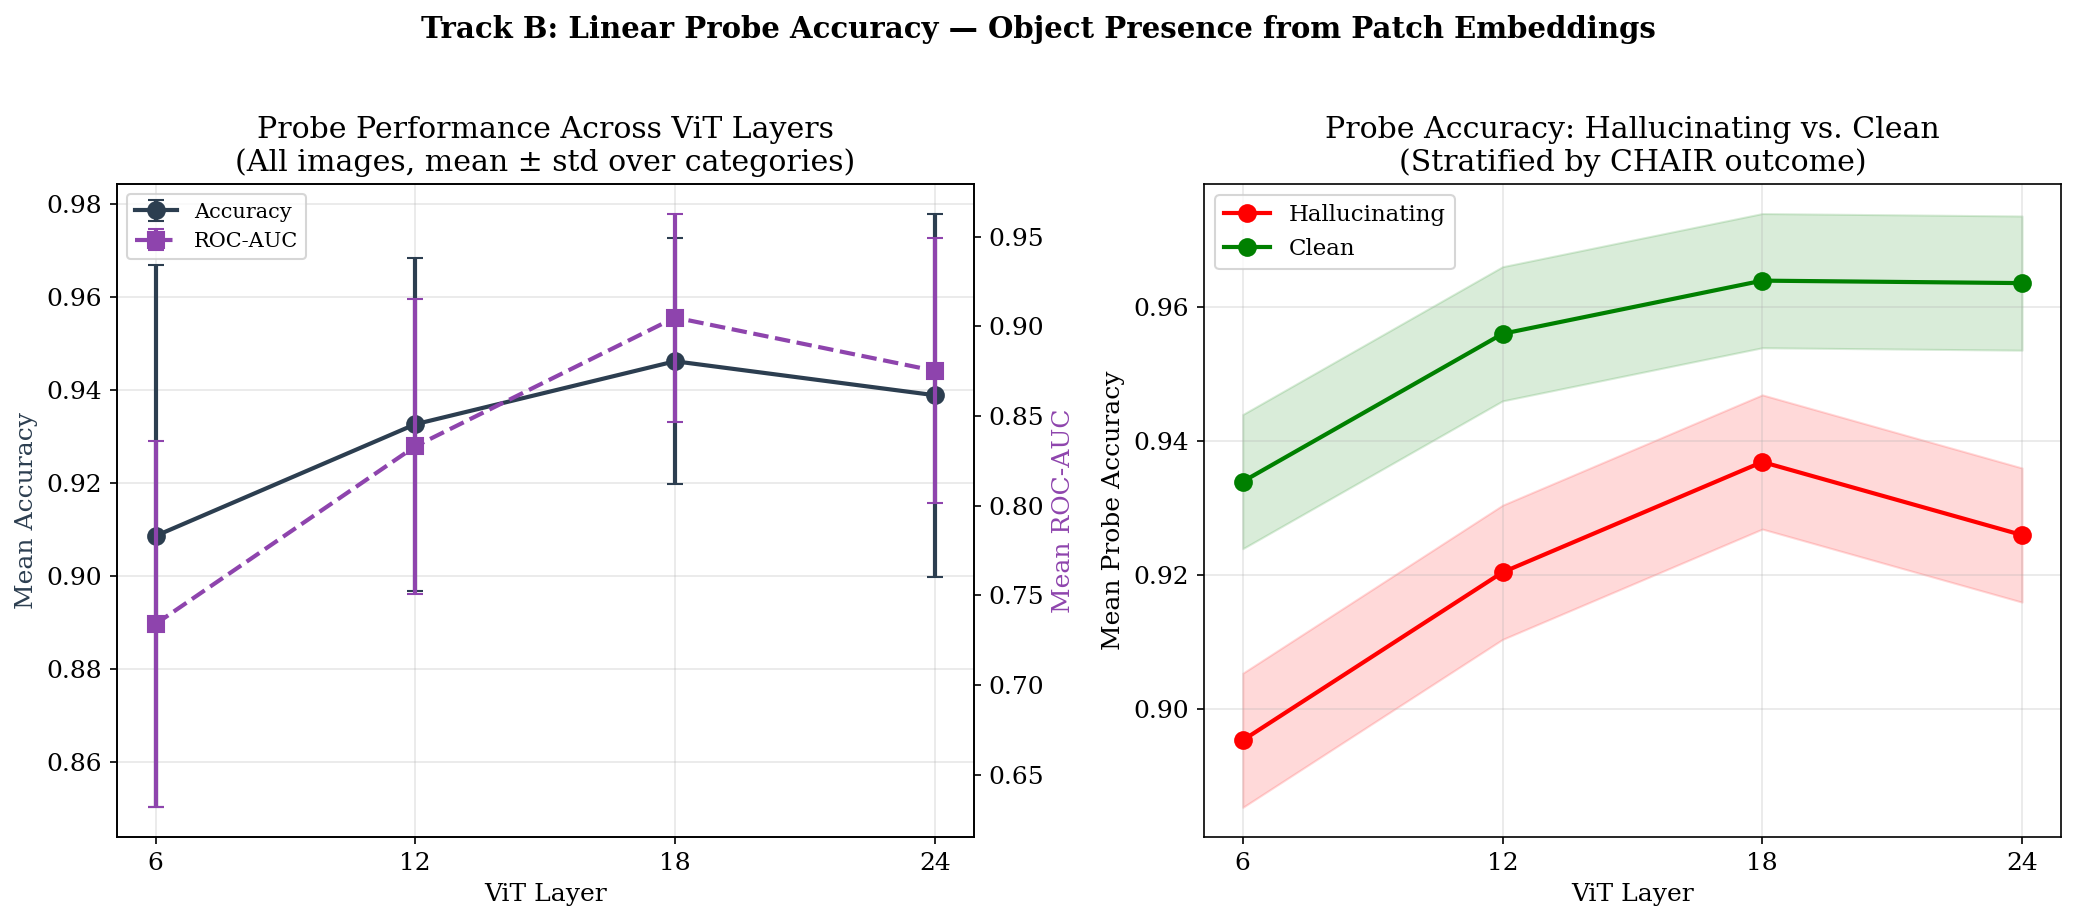

✅ Figure 1 saved.


In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
plt.rcParams.update({'font.family': 'serif', 'font.size': 12, 'figure.dpi': 150})

layer_summary = results_df.groupby('layer').agg(
    mean_acc=('acc_all', 'mean'),
    std_acc=('acc_all', 'std'),
    mean_auc=('auc_all', 'mean'),
    std_auc=('auc_all', 'std'),
    mean_acc_hall=('acc_hall', 'mean'),
    mean_acc_clean=('acc_clean', 'mean'),
    mean_auc_hall=('auc_hall', 'mean'),
    mean_auc_clean=('auc_clean', 'mean'),
    n_cats=('category', 'count'),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
x = layer_summary['layer'].values

# ── Panel A: Overall accuracy + AUC by layer ──
ax = axes[0]
ax.errorbar(x, layer_summary['mean_acc'], yerr=layer_summary['std_acc'],
            marker='o', lw=2, ms=8, color='#2c3e50', capsize=4, label='Accuracy')
ax2 = ax.twinx()
ax2.errorbar(x, layer_summary['mean_auc'], yerr=layer_summary['std_auc'],
             marker='s', lw=2, ms=8, color='#8e44ad', capsize=4, ls='--', label='ROC-AUC')
ax.set_xlabel('ViT Layer')
ax.set_ylabel('Mean Accuracy', color='#2c3e50')
ax2.set_ylabel('Mean ROC-AUC', color='#8e44ad')
ax.set_xticks(PROBE_LAYERS)
ax.set_title('Probe Performance Across ViT Layers\n(All images, mean ± std over categories)')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=10)
ax.grid(True, alpha=0.3)

# ── Panel B: Halluc vs Clean accuracy by layer ──
ax3 = axes[1]
ax3.plot(x, layer_summary['mean_acc_hall'],  'r-o', lw=2, ms=8, label='Hallucinating')
ax3.plot(x, layer_summary['mean_acc_clean'], 'g-o', lw=2, ms=8, label='Clean')
ax3.fill_between(x,
    layer_summary['mean_acc_hall'] - 0.01,
    layer_summary['mean_acc_hall'] + 0.01,
    alpha=0.15, color='red')
ax3.fill_between(x,
    layer_summary['mean_acc_clean'] - 0.01,
    layer_summary['mean_acc_clean'] + 0.01,
    alpha=0.15, color='green')
ax3.set_xlabel('ViT Layer')
ax3.set_ylabel('Mean Probe Accuracy')
ax3.set_title('Probe Accuracy: Hallucinating vs. Clean\n(Stratified by CHAIR outcome)')
ax3.set_xticks(PROBE_LAYERS)
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)

plt.suptitle('Track B: Linear Probe Accuracy — Object Presence from Patch Embeddings',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{TRACKB_DIR}/figure_probe_accuracy_curves.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ Figure 1 saved.")


## Cell 12 — Figure 2: Per-Category Probe AUC Heatmap

Heatmap of ROC-AUC per (layer, category) — shows which object categories  
are most and least linearly decodable from patch embeddings, and how this changes with depth.

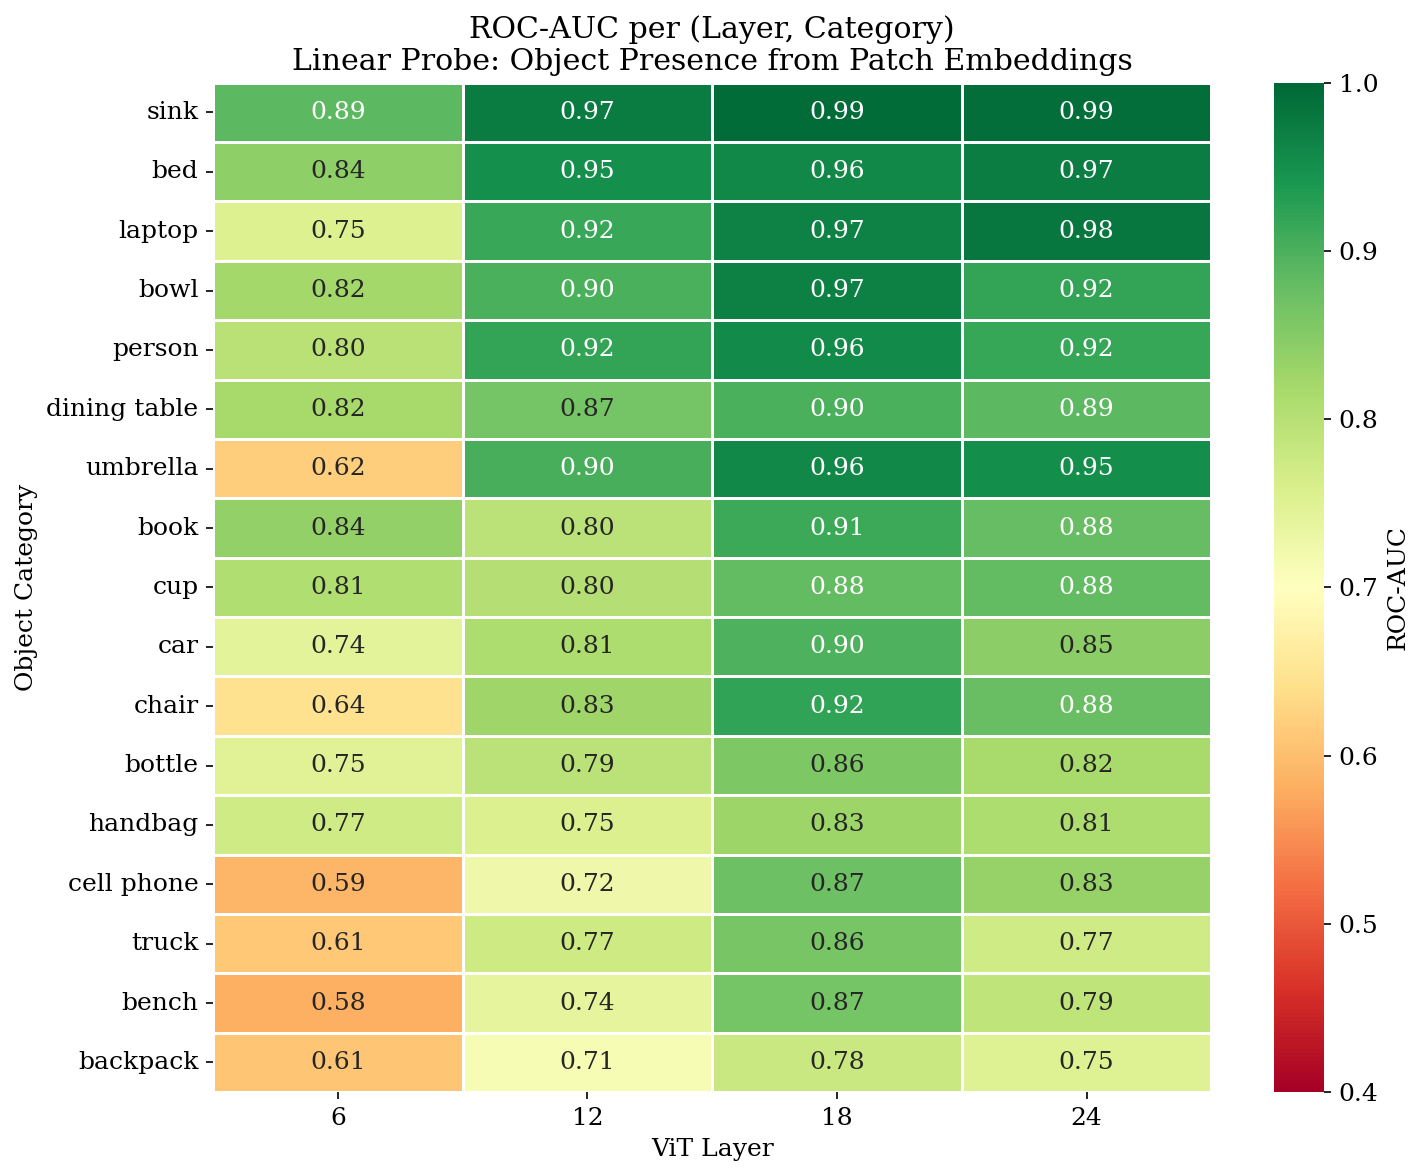

✅ Figure 2 saved.


In [12]:
import seaborn as sns

# Pivot: rows = categories, cols = layers
heatmap_df = results_df.pivot_table(index='category', columns='layer', values='auc_all')

# Sort by mean AUC descending for readability
heatmap_df = heatmap_df.loc[heatmap_df.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(10, max(8, len(heatmap_df) * 0.35)))
sns.heatmap(heatmap_df, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0.4, vmax=1.0, linewidths=0.5,
            cbar_kws={'label': 'ROC-AUC'},
            ax=ax)
ax.set_xlabel('ViT Layer')
ax.set_ylabel('Object Category')
ax.set_title('ROC-AUC per (Layer, Category)\nLinear Probe: Object Presence from Patch Embeddings')
plt.tight_layout()
plt.savefig(f"{TRACKB_DIR}/figure_probe_auc_heatmap.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ Figure 2 saved.")


## Cell 13 — Figure 3: Accuracy Delta (Halluc − Clean) by Layer

Key Track B result figure: if `acc_delta > 0`, probes are *more accurate* on hallucinating images  
(unexpected — could indicate the ViT encodes information correctly but LLM ignores it).  
If `acc_delta < 0`, patch embeddings are degraded for hallucinating images (supports hypothesis).

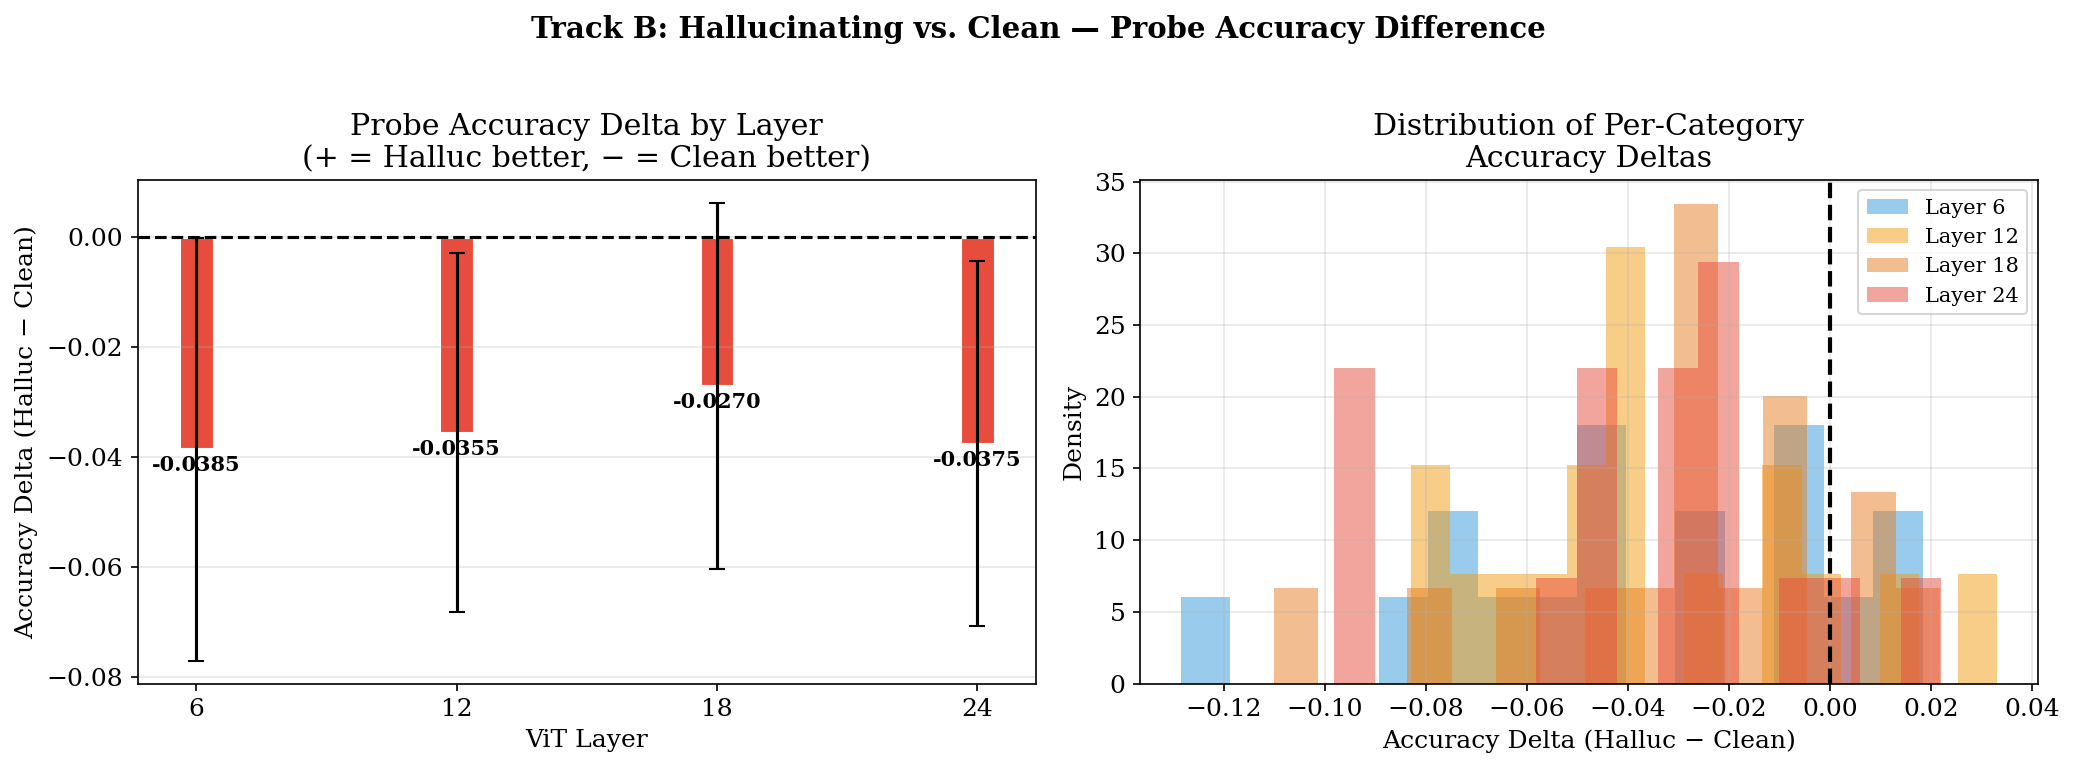

✅ Figure 3 saved.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

delta_by_layer = results_df.groupby('layer')['acc_delta'].agg(['mean', 'std', 'median']).reset_index()
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in delta_by_layer['mean']]

# ── Panel A: Mean delta per layer ──
bars = axes[0].bar(delta_by_layer['layer'], delta_by_layer['mean'], color=colors, edgecolor='white', lw=1.5)
axes[0].errorbar(delta_by_layer['layer'], delta_by_layer['mean'], yerr=delta_by_layer['std'],
                 fmt='none', color='black', capsize=4)
axes[0].axhline(0, color='black', lw=1.5, ls='--')
for b, v in zip(bars, delta_by_layer['mean']):
    axes[0].text(b.get_x() + b.get_width()/2, v + (0.002 if v >= 0 else -0.004),
                 f'{v:+.4f}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_xlabel('ViT Layer')
axes[0].set_ylabel('Accuracy Delta (Halluc − Clean)')
axes[0].set_title('Probe Accuracy Delta by Layer\n(+ = Halluc better, − = Clean better)')
axes[0].set_xticks(PROBE_LAYERS)
axes[0].grid(True, alpha=0.3, axis='y')

# ── Panel B: Distribution of per-category deltas ──
for layer_num, color in zip(PROBE_LAYERS, ['#3498db', '#f39c12', '#e67e22', '#e74c3c']):
    deltas = results_df[results_df['layer'] == layer_num]['acc_delta'].dropna()
    axes[1].hist(deltas, bins=15, alpha=0.5, color=color, label=f'Layer {layer_num}', density=True)

axes[1].axvline(0, color='black', lw=2, ls='--')
axes[1].set_xlabel('Accuracy Delta (Halluc − Clean)')
axes[1].set_ylabel('Density')
axes[1].set_title('Distribution of Per-Category\nAccuracy Deltas')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Track B: Hallucinating vs. Clean — Probe Accuracy Difference',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{TRACKB_DIR}/figure_probe_accuracy_delta.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ Figure 3 saved.")


## Cell 14 — Figure 4: AUC Delta (Halluc − Clean) by Layer + Top/Bottom Categories

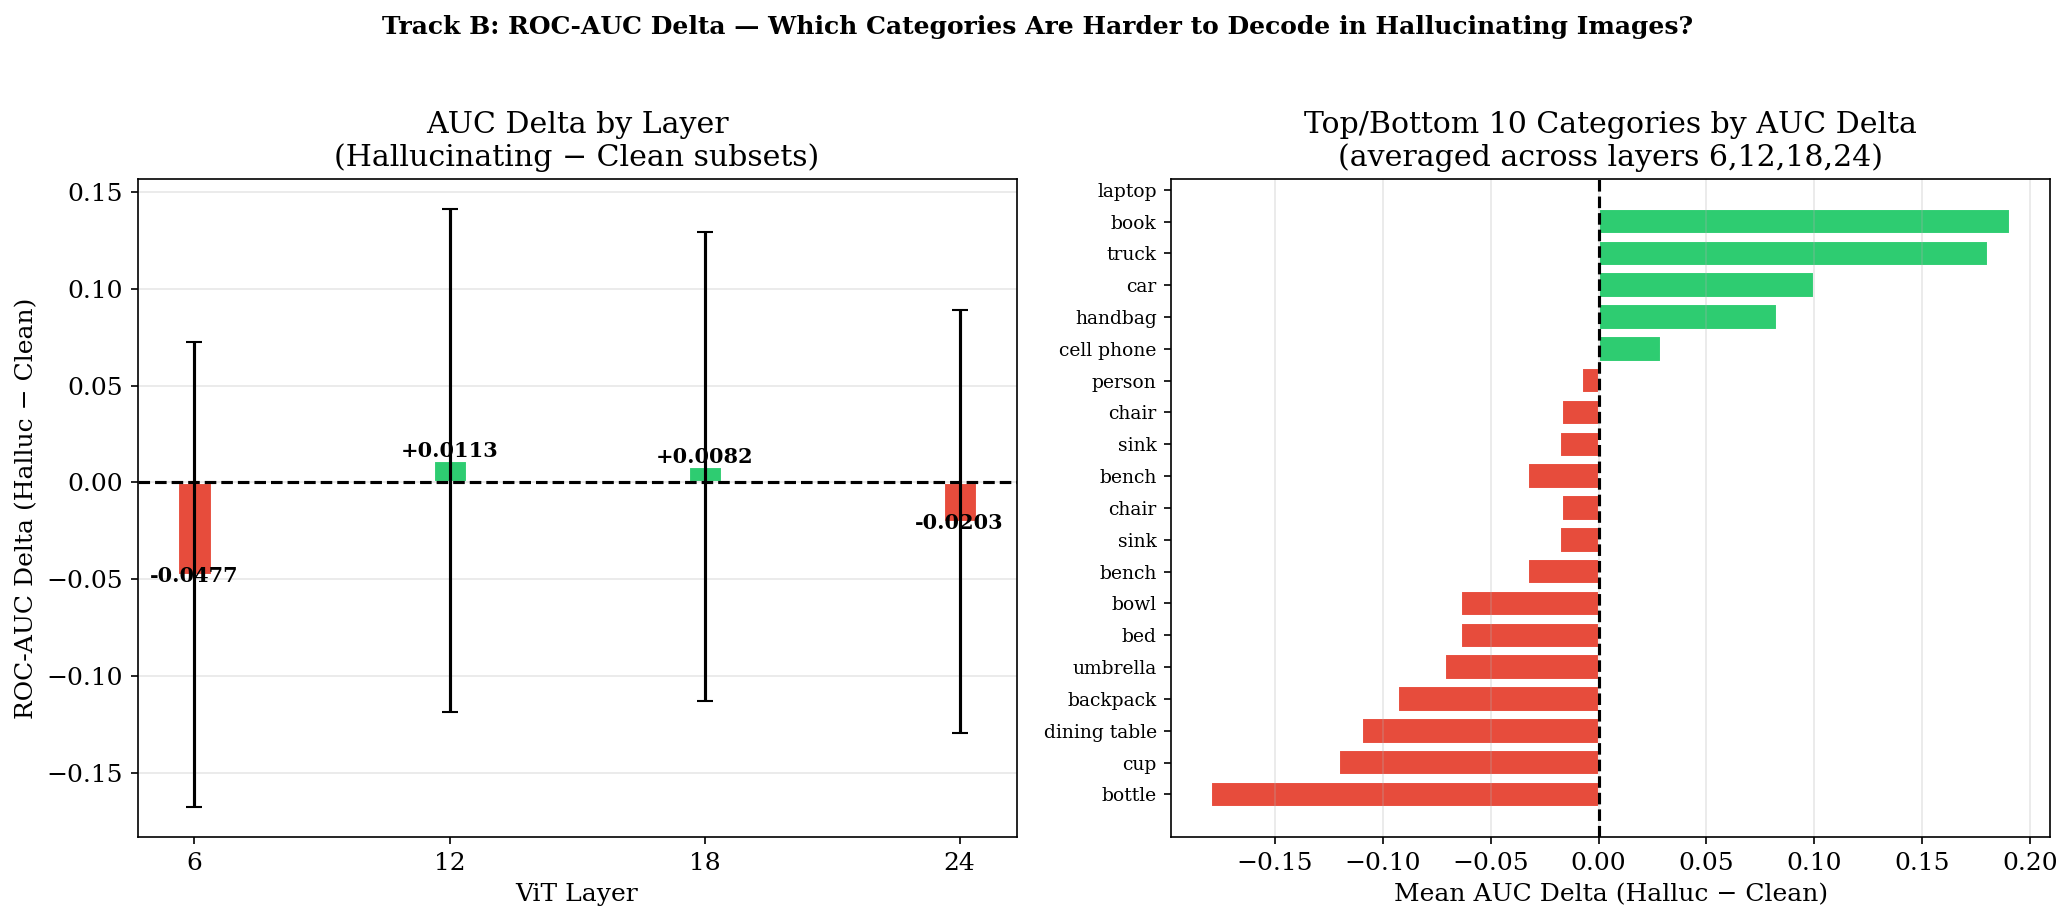

✅ Figure 4 saved.


In [14]:
results_df['auc_delta'] = results_df['auc_hall'] - results_df['auc_clean']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Panel A: AUC delta per layer ──
auc_delta_summary = results_df.groupby('layer')['auc_delta'].agg(['mean','std']).reset_index()
colors_auc = ['#e74c3c' if v < 0 else '#2ecc71' for v in auc_delta_summary['mean']]
bars_auc = axes[0].bar(auc_delta_summary['layer'], auc_delta_summary['mean'],
                       color=colors_auc, edgecolor='white', lw=1.5)
axes[0].errorbar(auc_delta_summary['layer'], auc_delta_summary['mean'],
                 yerr=auc_delta_summary['std'], fmt='none', color='black', capsize=4)
axes[0].axhline(0, color='black', lw=1.5, ls='--')
for b, v in zip(bars_auc, auc_delta_summary['mean']):
    axes[0].text(b.get_x()+b.get_width()/2, v+(0.002 if v>=0 else -0.004),
                 f'{v:+.4f}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_xlabel('ViT Layer')
axes[0].set_ylabel('ROC-AUC Delta (Halluc − Clean)')
axes[0].set_title('AUC Delta by Layer\n(Hallucinating − Clean subsets)')
axes[0].set_xticks(PROBE_LAYERS)
axes[0].grid(True, alpha=0.3, axis='y')

# ── Panel B: Top/bottom categories by mean AUC delta (across layers) ──
cat_delta = results_df.groupby('category')['auc_delta'].mean().sort_values()
n_show = min(10, len(cat_delta))
top_bottom = pd.concat([cat_delta.head(n_show), cat_delta.tail(n_show)])
colors_cat = ['#e74c3c' if v < 0 else '#2ecc71' for v in top_bottom.values]

axes[1].barh(range(len(top_bottom)), top_bottom.values, color=colors_cat, edgecolor='white')
axes[1].set_yticks(range(len(top_bottom)))
axes[1].set_yticklabels(top_bottom.index, fontsize=9)
axes[1].axvline(0, color='black', lw=1.5, ls='--')
axes[1].set_xlabel('Mean AUC Delta (Halluc − Clean)')
axes[1].set_title(f'Top/Bottom {n_show} Categories by AUC Delta\n(averaged across layers 6,12,18,24)')
axes[1].grid(True, alpha=0.3, axis='x')

plt.suptitle('Track B: ROC-AUC Delta — Which Categories Are Harder to Decode in Hallucinating Images?',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{TRACKB_DIR}/figure_probe_auc_delta.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ Figure 4 saved.")


## Cell 15 — Statistical Tests

Test whether probe accuracy is **significantly different** between hallucinating and clean subsets per layer.

In [15]:
from scipy.stats import wilcoxon, ttest_rel

print("="*65)
print("TRACK B — STATISTICAL RESULTS")
print("="*65)
print(f"\n{'Layer':>6} | {'Mean Acc':>9} | {'AUC':>6} | {'Δ Acc':>8} | {'Wilcoxon p':>12} | {'Sig?':>5}")
print("-"*65)

stats_rows = []
for layer_num in PROBE_LAYERS:
    sub = results_df[results_df['layer'] == layer_num].dropna(subset=['acc_hall', 'acc_clean'])
    if len(sub) < 5:
        continue

    hall_accs  = sub['acc_hall'].values
    clean_accs = sub['acc_clean'].values
    delta      = (hall_accs - clean_accs)

    # Wilcoxon signed-rank (paired, non-parametric)
    try:
        stat, p = wilcoxon(hall_accs, clean_accs)
    except Exception:
        p = 1.0

    sig = "✅" if p < 0.05 else "n.s."
    print(f"{layer_num:>6} | {sub['acc_all'].mean():>9.4f} | {sub['auc_all'].mean():>6.4f} | "
          f"{delta.mean():>+8.4f} | {p:>12.6f} | {sig:>5}")

    stats_rows.append({
        'layer': layer_num, 'mean_acc': sub['acc_all'].mean(),
        'mean_auc': sub['auc_all'].mean(), 'mean_delta': delta.mean(),
        'wilcoxon_p': p, 'significant': p < 0.05
    })

print("-"*65)
stats_df = pd.DataFrame(stats_rows)
stats_df.to_csv(f"{TRACKB_DIR}/probe_stats.csv", index=False)
print(f"\n✅ Stats saved.")


TRACK B — STATISTICAL RESULTS

 Layer |  Mean Acc |    AUC |    Δ Acc |   Wilcoxon p |  Sig?
-----------------------------------------------------------------
     6 |    0.9086 | 0.7340 |  -0.0386 |     0.000839 |     ✅
    12 |    0.9326 | 0.8331 |  -0.0355 |     0.000656 |     ✅
    18 |    0.9461 | 0.9049 |  -0.0270 |     0.004179 |     ✅
    24 |    0.9388 | 0.8752 |  -0.0376 |     0.000153 |     ✅
-----------------------------------------------------------------

✅ Stats saved.


## Cell 16 — Complete Summary + Milestone

In [16]:
print("="*65)
print("  TRACK B — COMPLETE RESULTS")
print("="*65)
print(f"\n📊 DATASET: {len(probe_df)} images")
print(f"   Hallucinating: {hall_mask.sum()} | Clean: {clean_mask.sum()}")
print(f"   Probe categories: {len(probing_cats)}")
print(f"   Total probes trained: {len(results_df)}")

print(f"\n📈 LAYER SUMMARY:")
print(results_df.groupby('layer')[['acc_all','auc_all','acc_hall','acc_clean','acc_delta']].mean().round(4).to_string())

best_layer = results_df.groupby('layer')['auc_all'].mean().idxmax()
print(f"\n🎯 Best layer by mean AUC: Layer {best_layer}")

mean_delta = results_df['acc_delta'].mean()
direction  = "Halluc > Clean" if mean_delta > 0 else "Clean > Halluc"
print(f"\n🔑 KEY FINDING:")
print(f"   Mean accuracy delta (Halluc−Clean): {mean_delta:+.4f}")
print(f"   Direction: {direction}")
if abs(mean_delta) < 0.01:
    print(f"   → 🟡 NULL RESULT: Patch embeddings equally discriminative in both groups.")
    print(f"      Suggests ViT encodes objects correctly regardless of hallucination outcome.")
elif mean_delta < 0:
    print(f"   → ✅ HYPOTHESIS SUPPORTED: Hallucinating images have less discriminative patch embeddings.")
else:
    print(f"   → ❌ HYPOTHESIS REVERSED: Patch embeddings MORE discriminative for hallucinating images.")
    print(f"      Possible explanation: LLM ignores good visual features (failure is post-encoder).")

print(f"\n📁 OUTPUTS in {TRACKB_DIR}:")
for f in ['probe_results.csv', 'probe_stats.csv', 'patch_embeddings_cache.npz',
          'figure_probe_accuracy_curves.png', 'figure_probe_auc_heatmap.png',
          'figure_probe_accuracy_delta.png', 'figure_probe_auc_delta.png']:
    exists = os.path.exists(f"{TRACKB_DIR}/{f}")
    print(f"   {'✅' if exists else '⬜'} {f}")

print(f"\n{'='*65}")
print(f"   Track B COMPLETE")
print(f"   → probe accuracy curves ready for Writing Team (Day 9)")
print(f"{'='*65}")


  TRACK B — COMPLETE RESULTS

📊 DATASET: 500 images
   Hallucinating: 329 | Clean: 171
   Probe categories: 17
   Total probes trained: 68

📈 LAYER SUMMARY:
       acc_all  auc_all  acc_hall  acc_clean  acc_delta
layer                                                  
6       0.9086   0.7340    0.8954     0.9340    -0.0385
12      0.9326   0.8331    0.9204     0.9560    -0.0355
18      0.9461   0.9049    0.9369     0.9639    -0.0270
24      0.9388   0.8752    0.9260     0.9635    -0.0375

🎯 Best layer by mean AUC: Layer 18

🔑 KEY FINDING:
   Mean accuracy delta (Halluc−Clean): -0.0347
   Direction: Clean > Halluc
   → ✅ HYPOTHESIS SUPPORTED: Hallucinating images have less discriminative patch embeddings.

📁 OUTPUTS in /content/drive/MyDrive/CS639_TrackA/TrackB:
   ✅ probe_results.csv
   ✅ probe_stats.csv
   ✅ patch_embeddings_cache.npz
   ✅ figure_probe_accuracy_curves.png
   ✅ figure_probe_auc_heatmap.png
   ✅ figure_probe_accuracy_delta.png
   ✅ figure_probe_auc_delta.png

   Track B